## STAT426 Final Project

NOTE: All runtimes in this project are given in seconds, and accuracy scores are given as values 0 < x < 1. 

In [2]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import time
import joblib
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn import svm
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

In [4]:
## Load the data
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
## Preprocess the data
train_images = train_images.reshape((-1, 28 * 28)).astype('float32') / 255.0
test_images = test_images.reshape((-1, 28 * 28)).astype('float32') / 255.0

In [6]:
# Split data into training and validation sets using a 80/20 ratio
train_images, val_images, train_labels, val_labels = train_test_split(train_images, train_labels,
                                                                      test_size=0.2,
                                                                      random_state=42)

In [7]:
# Normalize the training/validation data
scaler = StandardScaler()
train_images_scaled = scaler.fit_transform(train_images)
val_images_scaled = scaler.transform(val_images)
test_images_scaled = scaler.transform(test_images)

# Part 1

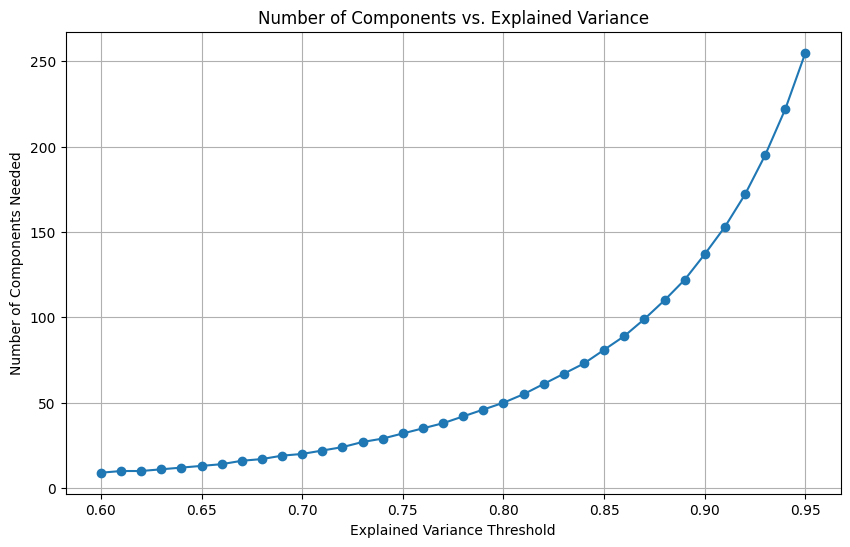

Number of components needed for 90% variance: 137


In [8]:
# Apply PCA, initialed with unknown number of components
pca = PCA(n_components=None)
# Fit PCA to training image
pca.fit(train_images_scaled)
# Calculate the cumulative explained variance ratio
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)
# Find the number of components required to explain 90% of the variance
n_components = np.argmax(cumulative_variance_ratio >= 0.90) + 1
pca = PCA(n_components=n_components)
variance_thresholds = np.arange(0.60, 0.96, 0.01)
# Find the number of components for each threshold
components_counts = [np.argmax(cumulative_variance_ratio >= threshold) + 1 for threshold in variance_thresholds]
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(variance_thresholds, components_counts, marker='o')
plt.title('Number of Components vs. Explained Variance')
plt.xlabel('Explained Variance Threshold')
plt.ylabel('Number of Components Needed')
plt.grid(True)
plt.show()
components_for_90 = components_counts[np.where(np.isclose(variance_thresholds, 0.90))[0][0]]
print(f'Number of components needed for 90% variance: {components_for_90}')

In [9]:
# You can now apply the updated PCA to the data
# (depending on the number of components you end up using)
train_images_pca = pca.fit_transform(train_images_scaled)
val_images_pca = pca.transform(val_images_scaled)
test_images_pca = pca.transform(test_images_scaled)

## Part 1 Answers
First, the number of components needed to account for 90% of the variance in the data is 137.

Using PCA for reducing dimensions makes the computations faster which simplifies the data structure and makes algorithm computation faster.

However, the tradeoff here is that using lower dimensions may take away information that was present in higher dimensions and creates a simpler result that may teeter away from perfect accuracy, so predictions may not be as precise. The key is to find a balance between dimensionality reduction and performance.

This method uses the instructions given in the question in that we are supposed to plot the number of components against the explained variance for the range 60-95% with 1% increment in each iteration, and plots that variance against the number of components needed to acheive that level of variance.

## Part 2

NOTE: The accuracy and runtime for this section are still given in seconds and 0 < x < 1 but is printed out for each iteration in the kNN algorithm for 1,3,...11

The kNN algorithm is a simple algorithm that will classify a point based on how close a testing data point is to a selected number k nearest training points. For the process, you first choose k and the parameter d, then compute d(xi, xi+1) for all i in n. Next, you order these, least to greatest, and then take the y value with the largest cardinality and return that as y(sub(n+1)).

In [10]:
# Initializing some parameters necessary for the question
k_values = [1,3,5,7,9,11]
results_original = {}
results_reduced = {}
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)
n_reduced_components = np.argmax(cumulative_variance_ratio >= 0.90) + 1
# Preliminary initialization for ORIGINAL
pca_original = PCA(n_components = 784)
x_train_original = pca_original.fit_transform(train_images_scaled)
x_test_original = pca_original.transform(test_images_scaled)
y_val_original = pca_original.transform(val_images_scaled)
# Preliminary initialization for REDUCED
pca_reduced = PCA(n_components = n_reduced_components)
x_train_reduced = pca_reduced.fit_transform(train_images_scaled)
x_test_reduced = pca_reduced.transform(test_images_scaled)
y_val_reduced = pca_reduced.transform(val_images_scaled)

In [11]:
# kNN for the original data
for k in k_values:
  knn_original = KNeighborsClassifier(n_neighbors = k)
  start_time = time.time()
  knn_original.fit(x_train_original, train_labels)
  y_prediction_original = knn_original.predict(x_test_original)
  accuracy_original = accuracy_score(test_labels, y_prediction_original)
  scores_original = cross_val_score(knn_original, train_images_scaled, train_labels, cv = 10)
  end_time = time.time()
  results_original[k] = {
      "accuracy": np.mean(scores_original),
        "time": end_time - start_time
  }
print(results_original)

{1: {'accuracy': 0.8471458333333333, 'time': 20.722963094711304}, 3: {'accuracy': 0.8522500000000001, 'time': 19.056262493133545}, 5: {'accuracy': 0.8545833333333333, 'time': 19.79877734184265}, 7: {'accuracy': 0.8531458333333333, 'time': 19.931333780288696}, 9: {'accuracy': 0.8521458333333334, 'time': 19.810738563537598}, 11: {'accuracy': 0.8505625, 'time': 22.05010199546814}}


In [12]:
# kNN for the reduced data
for k in k_values:
  knn_reduced = KNeighborsClassifier(n_neighbors = k)
  start_time = time.time()
  knn_reduced.fit(x_train_reduced, train_labels)
  y_prediction_reduced = knn_reduced.predict(x_test_reduced)
  accuracy_reduced = accuracy_score(test_labels, y_prediction_reduced)
  scores_reduced = cross_val_score(knn_reduced, train_images_pca, train_labels, cv = 10)
  end_time = time.time()
  results_reduced[k] = {
      "accuracy": np.mean(scores_reduced),
      "time": end_time - start_time
  }
print(results_reduced)

{1: {'accuracy': 0.8484375, 'time': 3.546792984008789}, 3: {'accuracy': 0.85875, 'time': 3.7992894649505615}, 5: {'accuracy': 0.8628958333333333, 'time': 3.8660686016082764}, 7: {'accuracy': 0.8627916666666667, 'time': 3.804274320602417}, 9: {'accuracy': 0.8617291666666667, 'time': 3.8660690784454346}, 11: {'accuracy': 0.8598333333333332, 'time': 3.9866652488708496}}


The two sections above are the kNN algorithms for both the original data and the PCA reduced dimension data. Looking at the runtimes and accuracies for each, one could conclude that the reduced data is more accurate, and it runs at a much quicker speed than the original one. The PCA reduced data runs in 137 dimensions while the original is 784. The need for doing this much calculation in this many dimensions is why the original data takes so much longer to run. My results show that the original data set takes ~70 seconds for each iteration to run, while the reduced data set takes only 10-15 seconds to run for each of six iterations. From Part 1, there was the question seeing if running faster sacrifices accuracy. To that, I say no, it does not sacrifice accuracy, even though it may be just slightly higher than the original data set.

In terms of the kNN algorithm/method, you have your training and testing data sets for the X parameters, and the y parameters are your labels, or classifiers. In this algorithm, you classify unknown, or testing data, based on what you have already trained the model with. Advantages of kNN include the fact that it is relatively easy to calculate, with only distance being a main factor, and that new data can be added at any time without fear of messing up the model. In terms of disadvantages, it is not good with large datasets because calculating the distance between every single point and every test point would take too long and is very costly. It is also not very good with higher dimensionality, as we saw here. It complicates the distance factor for each dimension when it has this many dimensions and overall is not efficient for high accuracy in this state.

In [13]:
best_k = max(results_reduced, key=lambda k: results_reduced[k]["accuracy"])
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(train_images_pca, train_labels)
joblib.dump(knn_best, 'knn_best.pkl')
print(f'Best k: {best_k}')
print(f'Accuracy on PCA data: {results_reduced[best_k]["accuracy"]}')
print(f'Run time on PCA data: {results_reduced[best_k]["time"]}')

Best k: 5
Accuracy on PCA data: 0.8628958333333333
Run time on PCA data: 3.8660686016082764


## Part 3

In [14]:
# SVM Code for Linear
start_time = time.time()
clfLinear = svm.SVC(kernel = 'linear')
clfLinear.fit(train_images_pca, train_labels)
y_prediction_linear = clfLinear.predict(test_images_pca)
accuracyLinear = accuracy_score(test_labels, y_prediction_linear)
end_time = time.time()
print(accuracyLinear)
print(end_time - start_time)

0.8474
160.37552046775818


In [15]:
# SVM Code for RBF
start_time = time.time()
clfRBF = svm.SVC(kernel = 'rbf')
clfRBF.fit(train_images_pca, train_labels)
y_prediction_RBF = clfRBF.predict(test_images_pca)
accuracyRBF = accuracy_score(test_labels, y_prediction_RBF)
end_time = time.time()
print(accuracyRBF)
print(end_time - start_time)

0.8774
53.12033414840698


In [17]:
# LDA Code
lda = LinearDiscriminantAnalysis()
start_time = time.time()
lda.fit(train_images_pca, train_labels)
y_pred_lda = lda.predict(test_images_pca)
accuracy_lda = accuracy_score(test_labels, y_pred_lda)
end_time = time.time()
print(accuracy_lda)
print(end_time - start_time)

0.8004
0.2684955596923828


In [18]:
# QDA Code
qda = QuadraticDiscriminantAnalysis()
start_time = time.time()
qda.fit(train_images_pca, train_labels)
y_pred_qda = qda.predict(test_images_pca)
accuracy_qda = accuracy_score(test_labels, y_pred_qda)
end_time = time.time()
print(accuracy_qda)
print(end_time - start_time)

0.6954
0.593944787979126


## Part 3 Answers and Descriptions of Methods
First, I will go over the runtime and accuracy for each of the learning methods in this part of the project.

Linear SVM by far takes the longest of these methods to run, but it is supported with pretty good accuracy at ~85%. This method is used when the data is perfectly linearly separable. It finds the most optimal hyperplane to separate the data into different classes with the maximum hyperplane length. Here, it took so long because it is in a high number of dimensions, which is computationally expensive. It takes in the training data and predicts where it will be classified, and then checks accuracy of the testing data against this training data (This is similar to how all of these methods work). The linear SVM is useful to avoid the high dimensionality, but it still took a long time to run. It is also memory efficient. It is not very suitable for non-linearly separable data.

RBF SVM can handle non-linear data well, and the decision boundary can be tuned by adjusting the kernel parameters, which makes it versatile when compared to other learning methods. It is also computationally expensive, which is shown in the relatively high runtime for this method. It can also start to overfit the data when given too many parameters. It is similar to all of the other methods with the parameters it takes in for fitting, testing, and prediction, and still yields high accuracy. In fact, when compared to the other models for this part of the project, it yielded the highest accuracy.

Next, I will talk about LDA and QDA. These two differ from the other learning methods covered in the project thus far. For one, these two methods completed compilation almost instantly, in under 4 seconds for each. However, this sacrifices accuracy, as both of these methods were lower than others, particularly QDA whose accuracy was only around 70%.

In depth, LDA provides simple, linear decision boundaries which are easy to understand, and is less prone to overfitting when compared to QDA. It is also useful when there is similar covariance with all parameters. A drawback of this method is that it only captures linear relationships and cannot perform well on complex datasets. It also assumes the Gaussian distribution, and the performance may degrade if the data is not distributed this way. Also, its performance may be affected by scale of the feature map. Therefore, again, it is not useful with complex data.

In transition, the bias-variance tradeoff is big when it comes to LDA vs QDA. More parameters need to be estimated for QDA. Thus, LDA has less flexibility and higher bias. There is lower variance in LDA as well. Contrary to this, QDA has lower bias and higher variance, which is supported in the accuracy score for the QDA in this project, as it had the lowest score out of any of the learning methods thus far.

Finally I will talk about QDA in bulk. It is flexible with decision boundaries and is good for finding relationships when classes have different covariance structures. It also assumes the Gaussian distribution and can be prone to overfitting as it takes in more parameters than LDA. Thus, the model may not perform well when the distribution deviates from the Gaussian.

Therefore, with all of these methods and including kNN from the prior part of the project, I would choose to use RBF SVM as a preferred learning method because it took the highest accuracy. Although it did not run the quickest, it did not take terribly long to run. This sacrifice, in my opinion, makes this the most worthy method of being chosen.

## Part 4

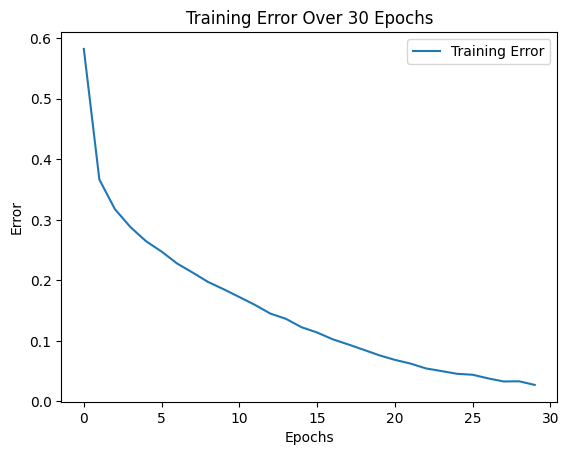

113.3094699382782


In [53]:
# Some building blocks for CNN

# Reshape data to fit the model

X_train = np.reshape(train_images, (-1, 28, 28, 1))
X_test = np.reshape(val_images, (-1, 28, 28, 1))

# Convert labels to categorical one-hot encoding
y_train = to_categorical(train_labels, num_classes=10)
y_test = to_categorical(val_labels, num_classes=10)

# Define the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
start_time = time.time()
history = model.fit(X_train, y_train, epochs=30, 
                    batch_size=128, validation_data=(X_test, y_test), 
                    verbose=0)
end_time = time.time()
print(end_time -start_time)
# Plot training error over epochs
plt.plot(history.history['loss'], label='Training Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.title('Training Error Over 30 Epochs')
plt.legend()
plt.show()



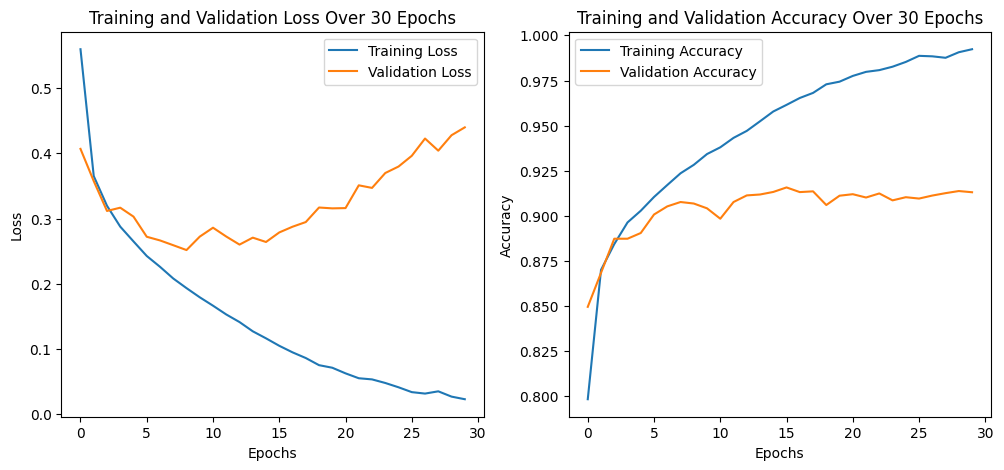

In [49]:
# Plot training and validation loss over epochs
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over 30 Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy Over 30 Epochs')
plt.legend()

plt.show()

c:\Users\ethan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


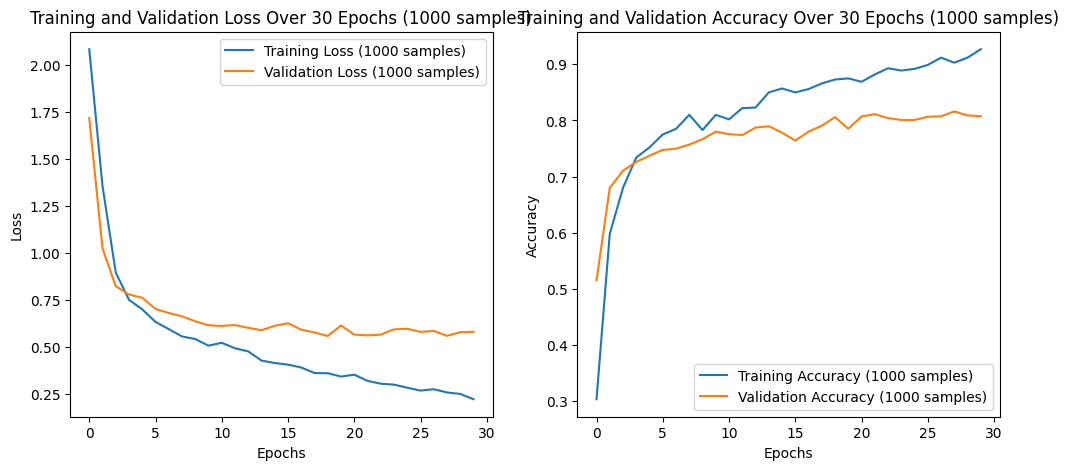

11.263465166091919


In [52]:
# Use only 1000 samples from the training set
X_train_small = X_train[:1000]
y_train_small = y_train[:1000]

# Define the CNN model

model_small = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
model_small.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with only 1000 samples
start_time = time.time()
history_small = model_small.fit(X_train_small, y_train_small, epochs=30, 
                                batch_size=128, validation_data=(X_test, y_test), 
                                verbose=0)
end_time = time.time()
print(end_time -start_time)
# Plot training and validation loss over epochs for the smaller dataset
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_small.history['loss'], label='Training Loss (1000 samples)')
plt.plot(history_small.history['val_loss'], label='Validation Loss (1000 samples)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over 30 Epochs (1000 samples)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_small.history['accuracy'], label='Training Accuracy (1000 samples)')
plt.plot(history_small.history['val_accuracy'], label='Validation Accuracy (1000 samples)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy Over 30 Epochs (1000 samples)')
plt.legend()

plt.show()


In [51]:
# Evaluate the model on the test set (full dataset)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy with full dataset: {test_accuracy:.4f}')

# Evaluate the model on the test set (1000 samples)
test_loss_small, test_accuracy_small = model_small.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy with 1000 samples: {test_accuracy_small:.4f}')

Test Accuracy with full dataset: 0.9131
Test Accuracy with 1000 samples: 0.8113


## Part 4 Write-up
First, CNNs are a type of deep learning model that are designed to process structured grid data like images, as is the case with this dataset we are using here. The idea behind CNN is the use of convolutional layers to automatically and adaptively learn spatial hierarchies of features from input images. These layers apply kernels that move across the image, detecting patterns in the image in deeper layers. The key parameters in CNN include number of filters, fulter size, among others. The choice of these parameters affects the network's ability to capture fine details vs. larger patterns in the data. A main advantage of CNN is the ability to capture spatial hierarchies in the data, making them highly effective for image and video recognition tasks. A downside is the large amount of data and computational resources to train effectively. 

DNNs are another class of deep learning models where a neuron in one layer is connected to every neuron in the next layer. These models are capable of learning complex representations by transforming data through multiple layers and transformations. The main parameters here are the number of layers, number of nodes per layer, batch size, and more. Choosing these parameters involves balance between model complexity and also carries the risk of overfitting. DNN is versatile and can be applied to many different tasks like classification, regression, and more. A main advantage it holds is its flexibility and ability to model complex relationships in the data. Again, it is prone to overfitting especially with small datasets. They also do not capture hierarchies like CNN, so they are not as suitable with image sets. 

In terms of accuracy over the other methods we went over for this project, CNN was the most accurate at just above 90% accuracy. In terms of runtime, the DNN sacrifices runtime and sample size for accuracy, but it still was not very accurate at only around 80%. This is comparable to all other learning methods in this project besides CNN which was by far the most accurate, even if it did not run the quickest. I think the smaller sample size does not capture as much variability within the data which is why it is less accurate than other learning methods. 

Finally, the testing accuracy improved by a lot with the CNN model compared to the other learning methods. 